Cover theory up above
Now that we've covered the theory, let's see if we can take that same toy model from the Toy Models of Superposition week and train an SAE on it

In [1]:
import gc
import itertools
import os
import random
import sys
from collections import Counter, defaultdict
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Any, Callable, Literal, TypeAlias

import circuitsvis as cv
import einops
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import torch as t
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from IPython.display import HTML, IFrame, display
from jaxtyping import Float, Int
from openai import OpenAI
from rich import print as rprint
from rich.table import Table
# from plotly_utils import imshow, line
import utils

/Users/jaredjunkin/Documents/weather_prediction/705-771-SAE-lectures/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
)
## It's insane how poorly maintained and versioned this directory is. Absolutely will be switchin to a better 
## SAE implementation next semester.
# from sae_lens import get_pretrained_saes_directory
# from sae_vis import SaeVisConfig, SaeVisData, SaeVisLayoutConfig
from tabulate import tabulate
from torch import Tensor, nn
from torch.distributions.categorical import Categorical
from torch.nn import functional as F
from tqdm.auto import tqdm
from transformer_lens import ActivationCache, HookedTransformer
from transformer_lens.hook_points import HookPoint
from transformer_lens.utils import get_act_name, test_prompt, to_numpy


In [3]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
from torch.nn.functional import relu

In [ ]:
def linear_lr(step, steps):
    return 1 - (step / steps)


def constant_lr(*_):
    return 1.0


def cosine_decay_lr(step, steps):
    return np.cos(0.5 * np.pi * step / (steps - 1))


@dataclass
class ToyModelConfig:
    # We optimize n_inst models in a single training loop to let us sweep over sparsity or importance
    # curves efficiently. You should treat the number of instances `n_inst` like a batch dimension,
    # but one which is built into our training setup. Ignore the latter 3 arguments for now, they'll
    # return in later exercises.
    n_inst: int
    n_features: int = 5
    d_hidden: int = 2
    n_correlated_pairs: int = 0
    n_anticorrelated_pairs: int = 0
    feat_mag_distn: Literal["unif", "normal"] = "unif"


class ToyModel(nn.Module):
    W: Float[Tensor, "inst d_hidden feats"]
    b_final: Float[Tensor, "inst feats"]

    # Our linear map (for a single instance) is x -> ReLU(W.T @ W @ x + b_final)

    def __init__(
        self,
        cfg: ToyModelConfig,
        feature_probability: float | Tensor = 0.01,
        importance: float | Tensor = 1.0,
        device=device,
    ):
        super(ToyModel, self).__init__()
        self.cfg = cfg

        if isinstance(feature_probability, float):
            feature_probability = t.tensor(feature_probability)
        self.feature_probability = feature_probability.to(device).broadcast_to(
            (cfg.n_inst, cfg.n_features)
        )
        if isinstance(importance, float):
            importance = t.tensor(importance)
        self.importance = importance.to(device).broadcast_to((cfg.n_inst, cfg.n_features))

        self.W = nn.Parameter(
            nn.init.xavier_normal_(t.empty((cfg.n_inst, cfg.d_hidden, cfg.n_features)))
        )
        self.b_final = nn.Parameter(t.zeros((cfg.n_inst, cfg.n_features)))
        self.device = device
        self.to(device)

    def forward(
        self,
        features: Float[Tensor, "... inst feats"],
    ) -> Float[Tensor, "... inst feats"]:
        """
        Performs a single forward pass. For a single instance, this is given by:
            x -> ReLU(W.T @ W @ x + b_final)
        """

        wtw = einops.einsum(self.W, self.W, 'i h f1, i h f2 -> i f1 f2')
        a = einops.einsum(wtw, features, 'i f1 f2 , ... i f2 -> ... i f1')
        out = F.relu(a + self.b_final)

        # wx = einops.einsum(self.W, features, 'i h f, ... i f -> ... i h')
        # a = einops.einsum(self.W, wx, 'i h f, ... i h -> ... i f')
        # out = F.relu(a + self.b_final)
        return out



    def generate_batch(self, batch_size: int) -> Float[Tensor, "batch inst feats"]:
        """
        Generates a batch of data of shape (batch_size, n_instances, n_features).
        """
        # generate random feature values
        features = torch.rand((batch_size, self.cfg.n_inst, self.cfg.n_features), device=self.device)
        # generate seed values
        probs = torch.rand((batch_size, self.cfg.n_inst, self.cfg.n_features), device=self.device) # why don't we need a random seed for each index
        
        # where probs <= feature_probability we set the feature to active, else 0
        batch = torch.where(probs <= self.feature_probability, input=features, other=0.0)


        return batch
    def calculate_loss(
        self,
        out: Float[Tensor, "batch inst feats"],
        batch: Float[Tensor, "batch inst feats"],
    ) -> Float[Tensor, ""]:
        """
        Calculates the loss for a given batch (as a scalar tensor), using this loss described in the
        Toy Models of Superposition paper:

            https://transformer-circuits.pub/2022/toy_model/index.html#demonstrating-setup-loss

        Note, `self.importance` is guaranteed to broadcast with the shape of `out` and `batch`.
        """
        # You'll fill this in later
        mean_residual = einops.reduce(self.importance * ((out - batch) ** 2), 'b i f ->i', reduction='mean')
        return mean_residual.sum()

    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 5_000,
        log_freq: int = 50,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float] = constant_lr,
    ):
        """
        Optimizes the model using the given hyperparameters.
        """
        optimizer = t.optim.Adam(self.parameters(), lr=lr)

        progress_bar = tqdm(range(steps))

        for step in progress_bar:
            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Optimize
            optimizer.zero_grad()
            batch = self.generate_batch(batch_size)
            out = self(batch)
            loss = self.calculate_loss(out, batch)
            loss.backward()
            optimizer.step()

            # Display progress bar
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(loss=loss.item() / self.cfg.n_inst, lr=step_lr)



In [42]:
cfg = ToyModelConfig(n_inst=8, n_features=5, d_hidden=2)

# importance varies within features for each instance
importance = 0.9 ** t.arange(cfg.n_features)

# sparsity is the same for all features in a given instance, but varies over instances
feature_probability = 50 ** -t.linspace(0, 1, cfg.n_inst)
model = ToyModel(
    cfg=cfg,
    device=device,
    importance=importance[None, :],
    feature_probability=feature_probability[:, None],
)
model.optimize()


100%|██████████| 5000/5000 [00:08<00:00, 561.89it/s, loss=0.0167, lr=0.001]


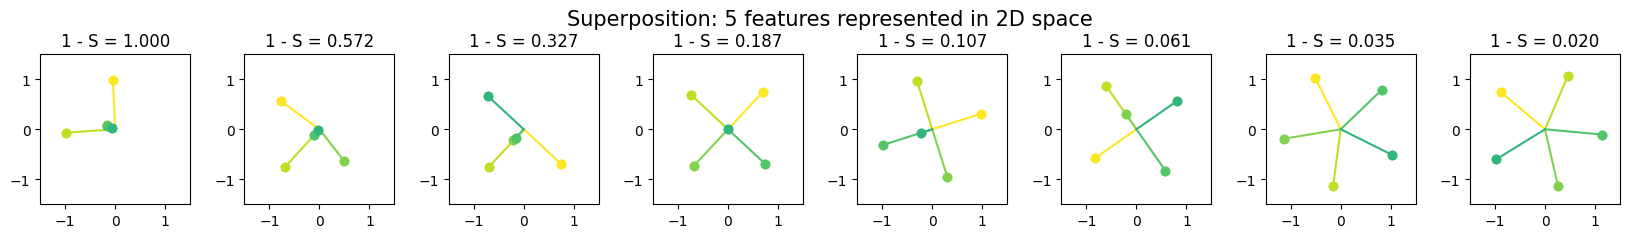

In [43]:
utils.plot_features_in_2d(
    model.W,
    colors=model.importance,
    title=f"Superposition: {cfg.n_features} features represented in 2D space",
    subplot_titles=[f"1 - S = {i:.3f}" for i in feature_probability.squeeze()],
)

# why does this appear to be learning all features at zero sparsity? is my penalty lower

# now that we've verified this works. Let's train a SAE to predict the features of this

In [ ]:
@dataclass
class ToySAEConfig:
    n_inst: int
    d_in: int
    d_sae: int
    sparsity_coeff: float = 0.2
    weight_normalize_eps: float = 1e-8
    tied_weights: bool = False
    ste_epsilon: float = 0.01


class ToySAE(nn.Module):
    W_enc: Float[Tensor, "inst d_in d_sae"]
    _W_dec: Float[Tensor, "inst d_sae d_in"] | None
    b_enc: Float[Tensor, "inst d_sae"]
    b_dec: Float[Tensor, "inst d_in"]

    def __init__(self, cfg: ToySAEConfig, model: ToyModel) -> None:
        super(ToySAE, self).__init__()

        assert cfg.d_in == model.cfg.d_hidden, "Model's hidden dim doesn't match SAE input dim"
        self.cfg = cfg
        self.model = model.requires_grad_(False)
        self.model.W.data[1:] = self.model.W.data[0]
        self.model.b_final.data[1:] = self.model.b_final.data[0]

        self.to(device)

    @property
    def W_dec(self) -> Float[Tensor, "inst d_sae d_in"]:
        return self._W_dec if self._W_dec is not None else self.W_enc.transpose(-1, -2)

    @property
    def W_dec_normalized(self) -> Float[Tensor, "inst d_sae d_in"]:
        """
        Returns decoder weights, normalized over the autoencoder input dimension.
        """
        # You'll fill this in later
        raise NotImplementedError()

    def generate_batch(self, batch_size: int) -> Float[Tensor, "batch inst d_in"]:
        """
        Generates a batch of hidden activations from our model.
        """
        # You'll fill this in later
        raise NotImplementedError()

    def forward(
        self, h: Float[Tensor, "batch inst d_in"]
    ) -> tuple[
        dict[str, Float[Tensor, "batch inst"]],
        Float[Tensor, "batch inst"],
        Float[Tensor, "batch inst d_sae"],
        Float[Tensor, "batch inst d_in"],
    ]:
        """
        Forward pass on the autoencoder.

        Args:
            h: hidden layer activations of model

        Returns:
            loss_dict:       dict of different loss terms, each having shape (batch_size, n_inst)
            loss:            total loss (i.e. sum over terms of loss dict), same shape as loss values
            acts_post:       autoencoder latent activations, after applying ReLU
            h_reconstructed: reconstructed autoencoder input
        """
        # You'll fill this in later
        raise NotImplementedError()

    def optimize(
        self,
        batch_size: int = 1024,
        steps: int = 10_000,
        log_freq: int = 100,
        lr: float = 1e-3,
        lr_scale: Callable[[int, int], float] = constant_lr,
        resample_method: Literal["simple", "advanced", None] = None,
        resample_freq: int = 2500,
        resample_window: int = 500,
        resample_scale: float = 0.5,
        hidden_sample_size: int = 256,
    ) -> list[dict[str, Any]]:
        """
        Optimizes the autoencoder using the given hyperparameters.

        Args:
            model:              we reconstruct features from model's hidden activations
            batch_size:         size of batches we pass through model & train autoencoder on
            steps:              number of optimization steps
            log_freq:           number of optimization steps between logging
            lr:                 learning rate
            lr_scale:           learning rate scaling function
            resample_method:    method for resampling dead latents
            resample_freq:      number of optimization steps between resampling dead latents
            resample_window:    number of steps needed for us to classify a neuron as dead
            resample_scale:     scale factor for resampled neurons
            hidden_sample_size: size of hidden value sample we add to the logs (for visualization)

        Returns:
            data_log:           dictionary containing data we'll use for visualization
        """
        assert resample_window <= resample_freq

        optimizer = t.optim.Adam(self.parameters(), lr=lr)  # betas=(0.0, 0.999)
        frac_active_list = []
        progress_bar = tqdm(range(steps))

        # Create lists of dicts to store data we'll eventually be plotting
        data_log = []

        for step in progress_bar:
            # Resample dead latents
            if (resample_method is not None) and ((step + 1) % resample_freq == 0):
                frac_active_in_window = t.stack(frac_active_list[-resample_window:], dim=0)
                if resample_method == "simple":
                    self.resample_simple(frac_active_in_window, resample_scale)
                elif resample_method == "advanced":
                    self.resample_advanced(frac_active_in_window, resample_scale, batch_size)

            # Update learning rate
            step_lr = lr * lr_scale(step, steps)
            for group in optimizer.param_groups:
                group["lr"] = step_lr

            # Get a batch of hidden activations from the model
            with t.inference_mode():
                h = self.generate_batch(batch_size)

            # Optimize
            loss_dict, loss, acts, _ = self.forward(h)
            loss.mean(0).sum().backward()
            optimizer.step()
            optimizer.zero_grad()

            # Normalize decoder weights by modifying them directly (if not using tied weights)
            if not self.cfg.tied_weights:
                self.W_dec.data = self.W_dec_normalized.data

            # Calculate the mean sparsities over batch dim for each feature
            frac_active = (acts.abs() > 1e-8).float().mean(0)
            frac_active_list.append(frac_active)

            # Display progress bar, and log a bunch of values for creating plots / animations
            if step % log_freq == 0 or (step + 1 == steps):
                progress_bar.set_postfix(
                    lr=step_lr,
                    loss=loss.mean(0).sum().item(),
                    frac_active=frac_active.mean().item(),
                    **{k: v.mean(0).sum().item() for k, v in loss_dict.items()},  # type: ignore
                )
                with t.inference_mode():
                    loss_dict, loss, acts, h_r = self.forward(
                        h := self.generate_batch(hidden_sample_size)
                    )
                data_log.append(
                    {
                        "steps": step,
                        "frac_active": (acts.abs() > 1e-8).float().mean(0).detach().cpu(),
                        "loss": loss.detach().cpu(),
                        "h": h.detach().cpu(),
                        "h_r": h_r.detach().cpu(),
                        **{name: param.detach().cpu() for name, param in self.named_parameters()},
                        **{name: loss_term.detach().cpu() for name, loss_term in loss_dict.items()},
                    }
                )

        return data_log

    @t.no_grad()
    def resample_simple(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
    ) -> None:
        """
        Resamples dead latents, by modifying the model's weights and biases inplace.

        Resampling method is:
            - For each dead neuron, generate a random vector of size (d_in,), and normalize these vecs
            - Set new values of W_dec and W_enc to be these normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()

    @t.no_grad()
    def resample_advanced(
        self,
        frac_active_in_window: Float[Tensor, "window inst d_sae"],
        resample_scale: float,
        batch_size: int,
    ) -> None:
        """
        Resamples latents that have been dead for `dead_feature_window` steps, according to `frac_active`.

        Resampling method is:
            - Compute the L2 reconstruction loss produced from the hidden state vecs `h`
            - Randomly choose values of `h` with probability proportional to their reconstruction loss
            - Set new values of W_dec & W_enc to be these centered & normalized vecs, at each dead neuron
            - Set b_enc to be zero, at each dead neuron
        """
        raise NotImplementedError()